# **Severe Incident Prediction Model**

Objective:
Predict whether an incident will be severe (Major/Fatal).

Business Value:
Helps identify high-risk workers, shifts, and conditions.

**Books**

In [ ]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

**Loading...**

In [ ]:
incidents = pd.read_csv("incidents.csv")
employees = pd.read_csv("employees.csv")
sites = pd.read_csv("sites.csv")

# Step 1: Merge incidents + employees
df = incidents.merge(
    employees,
    on="emp_id",
    how="left",
    suffixes=("", "_emp")
)

# Step 2: Merge sites
df = df.merge(
    sites,
    on="site_id",
    how="left",
    suffixes=("", "_site")
)

# Drop any duplicate employee columns
cols_to_drop = [col for col in df.columns if col.endswith("_emp")]
df.drop(columns=cols_to_drop, inplace=True)

# Drop any duplicate site columns
cols_to_drop = [col for col in df.columns if col.endswith("_site")]
df.drop(columns=cols_to_drop, inplace=True)

# Final check
print("Final columns:")
print(df.columns)

print(f"\nDataset ready: {df.shape[0]} rows")

Final columns:
Index(['emp_id', 'date', 'site_id', 'tenure_months', 'job_role', 'shift_type',
       'last_training_score', 'region', 'facility_type', 'site_age_years',
       'incident_type', 'body_part', 'severity_level', 'ppe_compliant',
       'inc_id'],
      dtype='object')

Dataset ready: 66 rows


**Target Locked**

In [ ]:
df["severe"] = (df["severity_level"] >= 3).astype(int)

**Feature Engineering**

In [ ]:
df["date"] = pd.to_datetime(df["date"])

df["day_of_month"] = df["date"].dt.day

**Feature Selection**

In [ ]:
features = [
    "tenure_months",
    "last_training_score",
    "shift_type",
    "job_role",
    "incident_type",
    "ppe_compliant",
    "facility_type",
    "site_age_years",
    "day_of_month"
]

X = df[features]
y = df["severe"]

**Encoding**

In [ ]:
for col in ["shift_type", "job_role", "incident_type", "facility_type"]:
    X[col] = LabelEncoder().fit_transform(X[col])

/tmp/ipykernel_6887/421655860.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipykernel_6887/421655860.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
/tmp/ipykernel_6887/421655860.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

**Train-Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Mowdel**

In [ ]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

**Evaluation**

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       0.00      0.00      0.00         2

    accuracy                           0.86        14
   macro avg       0.43      0.50      0.46        14
weighted avg       0.73      0.86      0.79        14

ROC-AUC: 0.5625


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Feature Importance**

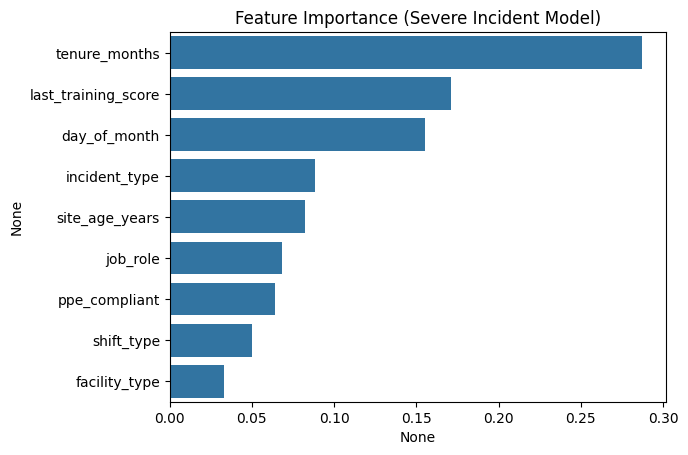

In [ ]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance (Severe Incident Model)")
plt.show()

/tmp/ipykernel_6887/2743888933.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  lambda x: (x["severity_level"] <= 2).sum() /
/tmp/ipykernel_6887/2743888933.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ratio = df.groupby("day_of_month").apply(


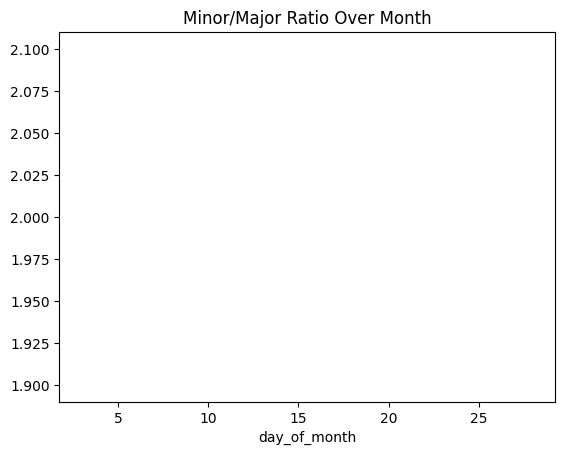

In [ ]:
ratio = df.groupby("day_of_month").apply(
    lambda x: (x["severity_level"] <= 2).sum() /
              (x["severity_level"] >= 3).sum()
)

ratio.plot(title="Minor/Major Ratio Over Month")
plt.show()